<a href="https://colab.research.google.com/github/DaffaAiraAdrn/DaffaAiraAdrin_2411531006_ML2526/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nilai K dari K-Fold dari 5 atau 10. dan tampilkan masing-masing nilai


PREPROCESSING DATA


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression #Model yang digunakan adalah LogisticRegression untuk klasifikasi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [4]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")
gender_submission_df = pd.read_csv("/content/gender_submission.csv") #dataset di upload pada google colab, tidak menggunakan gdrive

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Feature Selection from Dataset

In [6]:
features = ["Pclass",	"Sex",	"Age",	"SibSp",	"Parch","Fare",	"Embarked"] #penentuan feature variables

train_data = train_df[features].copy() #.copy() Mencegah perubahan tidak sengaja pada dataframe asli
test_data = test_df[features].copy()

y = train_df["Survived"] # target variable

Train Test Split untuk Perbandingan Holdout dan Cross-Validation

In [7]:
X_train, X_holdout, y_train, y_holdout = train_test_split(train_data,
                                                          y, test_size=0.2, random_state = 42, stratify=y)

HANDLING MISSING VALUE

In [8]:
X_train["Age"] = X_train["Age"].fillna(X_train["Age"].median()) # mengisi dengan median data
X_holdout["Age"] = X_holdout["Age"].fillna(X_train["Age"].median())
test_data["Age"] = test_data["Age"].fillna(X_train["Age"].median())

X_train["Fare"] = X_train["Fare"].fillna(X_train["Fare"].median())
X_holdout["Fare"] = X_holdout["Fare"].fillna(X_train["Fare"].median())
test_data["Fare"] = test_data["Fare"].fillna(X_train["Fare"].median())

X_train["Embarked"] = X_train["Embarked"].fillna(X_train["Embarked"].mode()[0]) #null diisi dengan modus untuk data kategorikal
X_holdout["Embarked"] = X_holdout["Embarked"].fillna(X_train["Embarked"].mode()[0])
test_data["Embarked"] = test_data["Embarked"].fillna(X_train["Embarked"].mode()[0])

MANUAL ENCODING

In [9]:
concat_df = pd.concat([X_train, X_holdout, test_data], axis=0)
concat_df = pd.get_dummies(concat_df, columns=["Sex", "Embarked"], drop_first=True).fillna(0)


In [10]:
X_train = concat_df.iloc[:len(X_train), :]
X_holdout = concat_df.iloc[len(X_train):len(X_train) + len(X_holdout), :]
X_test = concat_df.iloc[len(X_train) + len(X_holdout):, :] #Pembagian dataset

In [11]:
print(X_train.dtypes)
print(X_train.head())

Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object
     Pclass   Age  SibSp  Parch      Fare  Sex_male  Embarked_Q  Embarked_S
692       3  28.5      0      0   56.4958      True       False        True
481       2  28.5      0      0    0.0000      True       False        True
527       1  28.5      0      0  221.7792      True       False        True
855       3  18.0      0      1    9.3500     False       False        True
801       2  31.0      1      1   26.2500     False       False        True


SCALING


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_holdout = scaler.transform(X_holdout) #Scaling terhadap dataset
X_test = scaler.transform(X_test)

MODEL

In [13]:
model = LogisticRegression(max_iter=1000, random_state = 42) #Inisialisasi Model Logistic Regression dengan random_state 42 untuk memastikan konsistensi parameter

K-FOLD CROSS VALIDATION N = 5

In [31]:
kfold = KFold(n_splits = 5, shuffle=True, random_state = 42)
y_pred = cross_val_predict(model, X_train, y_train, cv=kfold)

print("\n=== Hasil Cross Validation")
print("Akurasi model: ", round(accuracy_score(y_train, y_pred), 3))
print("\nClassification Report")
print(classification_report(y_train, y_pred, target_names=["Tidak Selamat", "Selamat"]))
print("Confusion Matrix")
print(confusion_matrix(y_train, y_pred))


=== Hasil Cross Validation
Akurasi model:  0.802

Classification Report
               precision    recall  f1-score   support

Tidak Selamat       0.83      0.86      0.84       439
      Selamat       0.76      0.71      0.73       273

     accuracy                           0.80       712
    macro avg       0.79      0.78      0.79       712
 weighted avg       0.80      0.80      0.80       712

Confusion Matrix
[[377  62]
 [ 79 194]]


In [21]:
cv_scores = cross_val_score(model, X_train, y_train, cv=kfold)

print("\nCross Validation Scores")
print("Scores tiap fold : ", cv_scores)
print("Rata-rata tiap fold: ", round(cv_scores.mean(), 3))
print("Standar deviasi dari setiap fold: ", round(cv_scores.std(), 3))


Cross Validation Scores
Scores tiap fold :  [0.78321678 0.75524476 0.78873239 0.8028169  0.88028169]
Rata-rata tiap fold:  0.802
Standar deviasi dari setiap fold:  0.042


K-FOLD CROSS VALIDATION N = 10

In [30]:
kfold_ten = KFold(n_splits = 10, shuffle=True, random_state = 42)
y_pred_ten = cross_val_predict(model, X_train, y_train, cv=kfold_ten)

print("\n=== Hasil Cross Validation")
print("Akurasi model: ", round(accuracy_score(y_train, y_pred), 3))
print("\nClassification Report")
print(classification_report(y_train, y_pred_ten, target_names=["Tidak Selamat", "Selamat"]))
print("Confusion Matrix")
print(confusion_matrix(y_train, y_pred))


=== Hasil Cross Validation
Akurasi model:  0.801

Classification Report
               precision    recall  f1-score   support

Tidak Selamat       0.83      0.86      0.84       439
      Selamat       0.75      0.71      0.73       273

     accuracy                           0.80       712
    macro avg       0.79      0.78      0.79       712
 weighted avg       0.80      0.80      0.80       712

Confusion Matrix
[[376  63]
 [ 79 194]]


In [25]:
cv_scores_ten = cross_val_score(model, X_train, y_train, cv=kfold_ten)

print("\nCross Validation Scores")
print("Scores tiap fold : ", cv_scores_ten)
print("Rata-rata tiap fold: ", round(cv_scores_ten.mean(), 3))
print("Standar deviasi dari setiap fold: ", round(cv_scores_ten.std(), 3))


Cross Validation Scores
Scores tiap fold :  [0.80555556 0.75       0.74647887 0.76056338 0.77464789 0.77464789
 0.81690141 0.78873239 0.88732394 0.90140845]
Rata-rata tiap fold:  0.801
Standar deviasi dari setiap fold:  0.052


Confusion Matrix untuk KFold Cross Validation dengan nilai n = 5

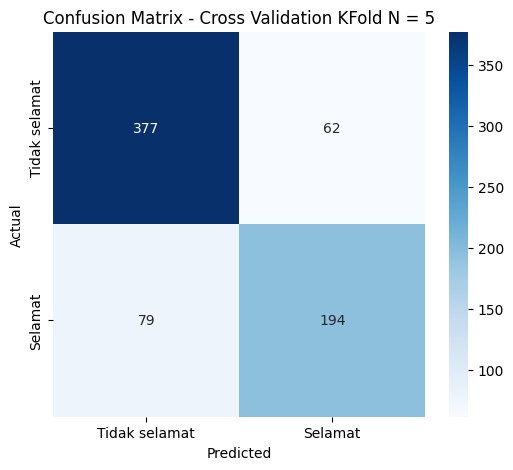

In [32]:
cm = confusion_matrix(y_train, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tidak selamat", "Selamat"],
            yticklabels=["Tidak selamat", "Selamat"]
            )

plt.title("Confusion Matrix - Cross Validation KFold N = 5")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix untuk KFold Cross Validation N = 10

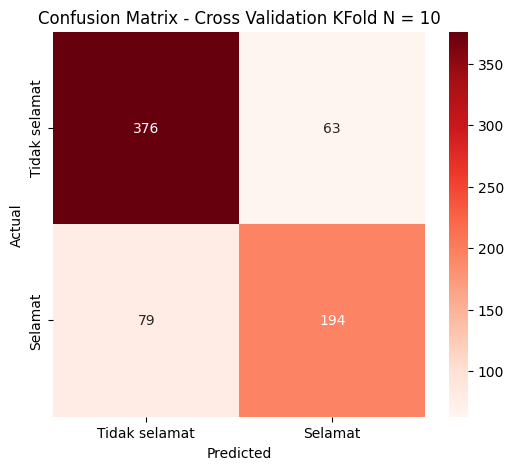

In [34]:
cm_ten = confusion_matrix(y_train, y_pred_ten)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ten, annot=True, fmt='d', cmap='Reds',
            xticklabels=["Tidak selamat", "Selamat"],
            yticklabels=["Tidak selamat", "Selamat"]
            )

plt.title("Confusion Matrix - Cross Validation KFold N = 10")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

HOLDOUT EVALUATION


In [41]:
model.fit(X_train, y_train)

y_holdout_pred = model.predict(X_holdout)

print("\n===Holdout Result===")
print("Akurasi: ", round(accuracy_score(y_holdout, y_holdout_pred), 3))
print("\nClassification Report")
print(classification_report(y_holdout, y_holdout_pred, target_names=["Tidak Selamat", "Selamat"]))
print("Confusion Matrix")
print(confusion_matrix(y_holdout, y_holdout_pred))


===Holdout Result===
Akurasi:  0.804

Classification Report
               precision    recall  f1-score   support

Tidak Selamat       0.81      0.89      0.85       110
      Selamat       0.79      0.67      0.72        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179

Confusion Matrix
[[98 12]
 [23 46]]


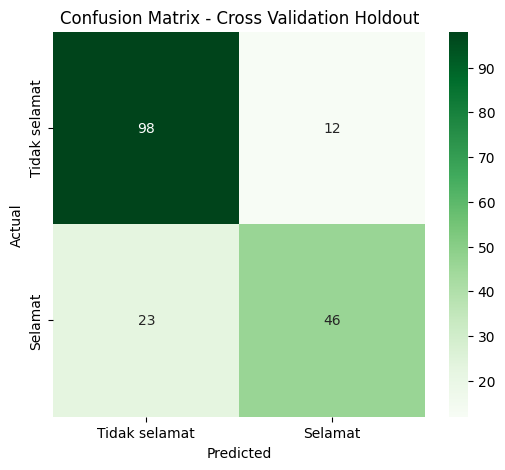

In [42]:
cm_holdout = confusion_matrix(y_holdout, y_holdout_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_holdout, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Tidak selamat", "Selamat"],
            yticklabels=["Tidak selamat", "Selamat"]
            )

plt.title("Confusion Matrix - Cross Validation Holdout")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

PREDIKSI MODEL SETELAH PELATIHAN DATA HOLDOUT

In [43]:
test_pred = model.predict(X_test)

prediksi = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_pred
})

original = gender_submission_df["Survived"]
prediksi = prediksi["Survived"]

akurasi = accuracy_score(original, prediksi)
print("\n===Akurasi Prediksi Model terhadap data original")
print("Akurasi prediksi model: ", round(akurasi, 3))
print(classification_report(original, prediksi, target_names=["Tidak Selamat", "Selamat"]))







===Akurasi Prediksi Model terhadap data original
Akurasi prediksi model:  0.943
               precision    recall  f1-score   support

Tidak Selamat       0.96      0.95      0.95       266
      Selamat       0.92      0.93      0.92       152

     accuracy                           0.94       418
    macro avg       0.94      0.94      0.94       418
 weighted avg       0.94      0.94      0.94       418



Visualisasi Confusion Matrix prediksi Holdout

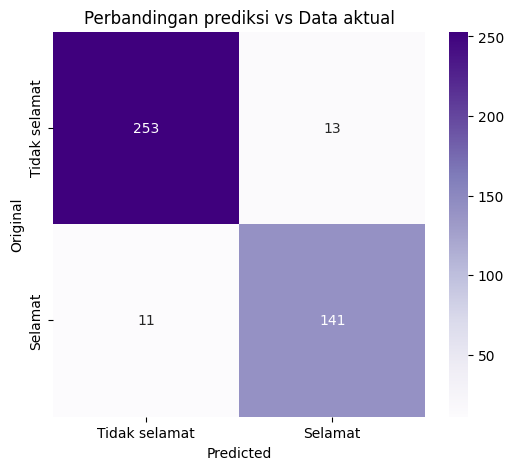

In [44]:
cm_compare = confusion_matrix(original, prediksi)

plt.figure(figsize=(6,5))
sns.heatmap(cm_compare, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Tidak selamat", "Selamat"],
            yticklabels=["Tidak selamat", "Selamat"])

plt.title("Perbandingan prediksi vs Data aktual")
plt.xlabel("Predicted")
plt.ylabel("Original")
plt.show()
